# Gemma 4 E4B CPU K/V-Cache Report

This notebook reports only the Gemma 4 E4B CPU experiments in this repository:
decode speed, WikiText-2 perplexity, deterministic prompt quality, and
chat-subagent quality judging. All figures are embedded as PNG outputs so the
report renders without JavaScript or notebook trust configuration.


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\">\n<style>\n.tq-report { font-family: -apple-system, BlinkMacSystemFont, \"Segoe UI\", sans-serif; background: #ffffff !important; color: #111827 !important; padding: 14px; border-radius: 6px; }\n.tq-report table { border-collapse: collapse; width: 100%; margin: 0.7rem 0 1.2rem 0; font-size: 13px; }\n.tq-report th { background: #f3f4f6 !important; color: #111827 !important; font-weight: 700; }\n.tq-report td { background: #ffffff !important; color: #111827 !important; }\n.tq-report th, .tq-report td { border: 1px solid #d1d5db; padding: 8px 10px; vertical-align: top; }\n.tq-report .tight td { padding: 6px 8px; }\n.tq-report .metric { font-weight: 700; color: #0f172a; }\n.tq-report .note { color: #4b5563; font-size: 13px; }\n</style>\n<table class=\"tight\"><thead><tr><th>Finding</th><th>Value</th></tr></thead><tbody><tr><td>Fastest 8K K/V setting</td><td>TBQ4/TBQ4 at 9.193 tok/s</td></tr><tr><td>8K speedup vs F16/F16</td><td>+30.0%</td></tr><tr><td>8K speedup vs Q8/Q8</td><td>+7.2%</td></tr><tr><td>Best 20-chunk PPL</td><td>TBQ4/TBQ4 at 113.8643</td></tr><tr><td>Completed quality prompts</td><td>8 prompts x 5 K/V settings</td></tr><tr><td>Quality prompt set</td><td>hard (gemma4_e4b_hard_generations.jsonl), n_predict=256</td></tr><tr><td>Primary caveat</td><td>Lexical metrics are proxies; the chat-subagent judge table is included when available for the selected prompt set.</td></tr></tbody></table></div>"))


Finding,Value
Fastest 8K K/V setting,TBQ4/TBQ4 at 9.193 tok/s
8K speedup vs F16/F16,+30.0%
8K speedup vs Q8/Q8,+7.2%
Best 20-chunk PPL,TBQ4/TBQ4 at 113.8643
Completed quality prompts,8 prompts x 5 K/V settings
Quality prompt set,"hard (gemma4_e4b_hard_generations.jsonl), n_predict=256"
Primary caveat,Lexical metrics are proxies; the chat-subagent judge table is included when available for the selected prompt set.


## Experimental Setup

The reported run is CPU-only on the local x86 host. No GPU acceleration is included in these measurements.


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table class=\"tight\"><thead><tr><th>Field</th><th>Value</th></tr></thead><tbody><tr><td>CPU</td><td>12th Gen Intel(R) Core(TM) i5-12500</td></tr><tr><td>Architecture</td><td>x86_64</td></tr><tr><td>Logical CPUs</td><td>12</td></tr><tr><td>Cores / socket</td><td>6</td></tr><tr><td>Threads / core</td><td>2</td></tr><tr><td>Caches</td><td>L2 7.5 MiB (6 instances), L3 18 MiB (1 instance)</td></tr><tr><td>Backend</td><td>CPU only; GPU layers set to 0 for quality/perplexity runs</td></tr><tr><td>Threads used in reported Gemma 4 runs</td><td>6</td></tr></tbody></table></div>"))


Field,Value
CPU,12th Gen Intel(R) Core(TM) i5-12500
Architecture,x86_64
Logical CPUs,12
Cores / socket,6
Threads / core,2
Caches,"L2 7.5 MiB (6 instances), L3 18 MiB (1 instance)"
Backend,CPU only; GPU layers set to 0 for quality/perplexity runs
Threads used in reported Gemma 4 runs,6


## Benchmark Inputs

The speed benchmark is decode-only. The qualitative benchmark uses the selected prompt set shown below; these prompts define the scope of the current quality claim.


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table class=\"tight\"><thead><tr><th>Test</th><th>Prompt/input source</th><th>Details</th></tr></thead><tbody><tr><td>Decode speed</td><td>No natural-language prompt</td><td>`llama-bench` used n_prompt=0 and n_gen=16; this is decode-only throughput.</td></tr><tr><td>Perplexity</td><td>WikiText-2 raw validation text</td><td>20 chunks, ctx=512, 6 CPU threads, flash attention enabled.</td></tr><tr><td>Deterministic quality and judge</td><td>hard prompt set</td><td>Each prompt was run for F16/F16, Q8/Q8, Q4/Q4, TBQ4/TBQ4, and Q8/TBQ4.</td></tr></tbody></table><table><thead><tr><th>ID</th><th>Category</th><th>Exact prompt</th><th>Reference used for cosine proxy</th></tr></thead><tbody><tr><td>1</td><td>Reasoning</td><td>A CPU benchmark reports 7.07 tokens/s for F16 KV and 9.19 tokens/s for TBQ4 KV at 8K context. In exactly three sentences, compute the percent speedup, state whether the result alone proves quality is preserved, and name one additional evaluation needed.</td><td>The speedup is (9.19 / 7.07 - 1) * 100, which is about 30%. This speed result alone does not prove quality is preserved. A quality check such as perplexity, task accuracy, or human/LLM judging is still needed.</td></tr><tr><td>2</td><td>Counterfact.</td><td>Answer carefully: If all birds could swim but only some birds could fly, would &#x27;can fly&#x27; be a reliable test for being a bird? Give a two-sentence answer and include the word &#x27;No&#x27;.</td><td>No, flying would not be a reliable test for being a bird because only some birds can fly in this scenario. Swimming would be shared by all birds, but it would still not necessarily distinguish birds from other animals unless no other animals could swim.</td></tr><tr><td>3</td><td>JSON</td><td>Return only valid JSON with keys answer, arithmetic, and caveat. Question: a 512-token cache uses 1.2 GB and an 8192-token cache scales linearly; how much memory is needed at 8192 tokens?</td><td>{&quot;answer&quot;:&quot;19.2 GB&quot;,&quot;arithmetic&quot;:&quot;1.2 * (8192 / 512) = 19.2&quot;,&quot;caveat&quot;:&quot;linear scaling is an assumption&quot;}</td></tr><tr><td>4</td><td>Instructions</td><td>Write exactly four bullet points. Each bullet must start with one of these labels in this order: Risk, Evidence, Mitigation, Next. Topic: using a fast K/V quantization result in a paper.</td><td>- Risk: A speed-only result can overstate the reliability of the quantization method.<br>- Evidence: Report throughput together with perplexity and task-level quality metrics.<br>- Mitigation: Use conservative claims and disclose model, hardware, context, and generation settings.<br>- Next: Replicate on additional prompts, longer generations, and another CPU architecture.</td></tr><tr><td>5</td><td>Summary</td><td>Summarize this paragraph in exactly 35 to 45 words:<br>TBQ4 improved long-context decode speed for Gemma 4 E4B on one Intel desktop CPU. However, the initial quality set used only five simple prompts and a short generation budget, making it hard to detect subtle degradation. The result is encouraging but not sufficient for a broad paper claim.</td><td>TBQ4 sped up long-context Gemma 4 E4B decoding on one Intel CPU, but the first quality test was too small and short to expose subtle regressions. The result is promising, yet broader evaluation is needed.</td></tr><tr><td>6</td><td>Code debug</td><td>Fix this Python function and return only the corrected code:<br><br>def mean(xs):<br>    total = 0<br>    for x in xs:<br>        total += x<br>    return total / len(x)<br></td><td>def mean(xs):<br>    total = 0<br>    for x in xs:<br>        total += x<br>    return total / len(xs)</td></tr><tr><td>7</td><td>Puzzle</td><td>Three boxes are labeled Apples, Oranges, and Mixed. Every label is wrong. You may draw one fruit from one box. Which box should you draw from to identify all boxes, and why?</td><td>Draw from the box labeled Mixed. Since every label is wrong, that box contains only apples or only oranges; the fruit drawn reveals which. Then the remaining two boxes can be assigned by eliminating the labels that must be wrong.</td></tr><tr><td>8</td><td>Medical</td><td>A friend suddenly has one-sided arm weakness and slurred speech but says they want to sleep it off. Respond in two short paragraphs: first explain what to do now, then explain why.</td><td>Call emergency services immediately and do not let them sleep it off. Note the time symptoms began and keep them safe while waiting for help.<br><br>One-sided weakness and slurred speech can be stroke symptoms, and stroke treatment is time-sensitive. Fast medical care can reduce brain injury and improve outcomes.</td></tr></tbody></table></div>"))


TestPrompt/input sourceDetailsDecode speedNo natural-language prompt`llama-bench` used n_prompt=0 and n_gen=16; this is decode-only throughput.PerplexityWikiText-2 raw validation text20 chunks, ctx=512, 6 CPU threads, flash attention enabled.Deterministic quality and judgehard prompt setEach prompt was run for F16/F16, Q8/Q8, Q4/Q4, TBQ4/TBQ4, and Q8/TBQ4.IDCategoryExact promptReference used for cosine proxy1ReasoningA CPU benchmark reports 7.07 tokens/s for F16 KV and 9.19 tokens/s for TBQ4 KV at 8K context. In exactly three sentences, compute the percent speedup, state whether the result alone proves quality is preserved, and name one additional evaluation needed.The speedup is (9.19 / 7.07 - 1) * 100, which is about 30%. This speed result alone does not prove quality is preserved. A quality check such as perplexity, task accuracy, or human/LLM judging is still needed.2Counterfact.Answer carefully: If all birds could swim but only some birds could fly, would &#x27;can fly&#x27; be a reliable test for being a bird? Give a two-sentence answer and include the word &#x27;No&#x27;.No, flying would not be a reliable test for being a bird because only some birds can fly in this scenario. Swimming would be shared by all birds, but it would still not necessarily distinguish birds from other animals unless no other animals could swim.3JSONReturn only valid JSON with keys answer, arithmetic, and caveat. Question: a 512-token cache uses 1.2 GB and an 8192-token cache scales linearly; how much memory is needed at 8192 tokens?{&quot;answer&quot;:&quot;19.2 GB&quot;,&quot;arithmetic&quot;:&quot;1.2 * (8192 / 512) = 19.2&quot;,&quot;caveat&quot;:&quot;linear scaling is an assumption&quot;}4InstructionsWrite exactly four bullet points. Each bullet must start with one of these labels in this order: Risk, Evidence, Mitigation, Next. Topic: using a fast K/V quantization result in a paper.- Risk: A speed-only result can overstate the reliability of the quantization method.- Evidence:

## Decode Speed

The main speed question is how K/V cache format changes decode throughput as KV depth grows. TBQ4/TBQ4 is the fastest tested configuration at 8K depth.


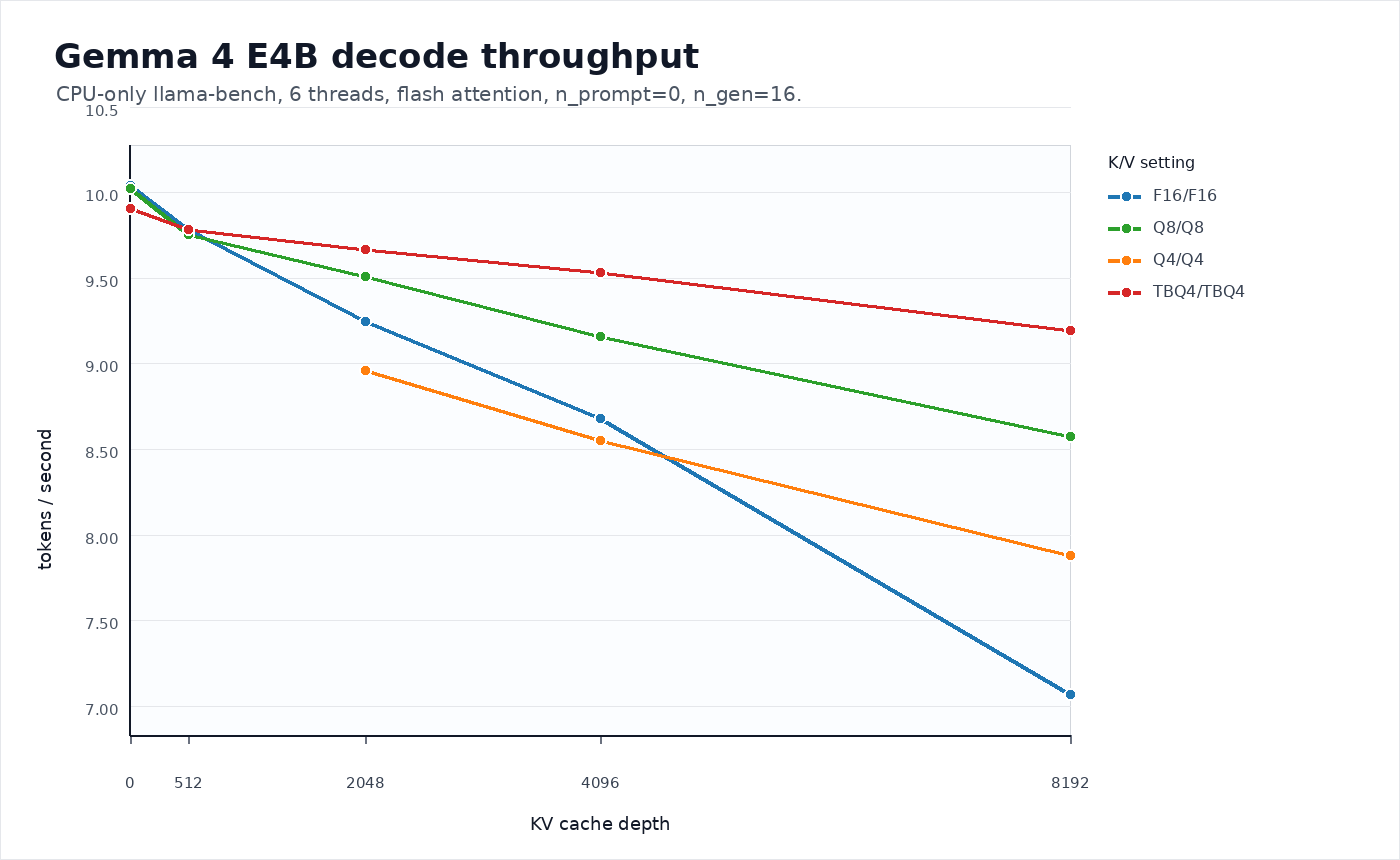

In [1]:
# Gemma 4 E4B decode throughput
# Generated by turboquant/autoresearch/make_report_notebook.py


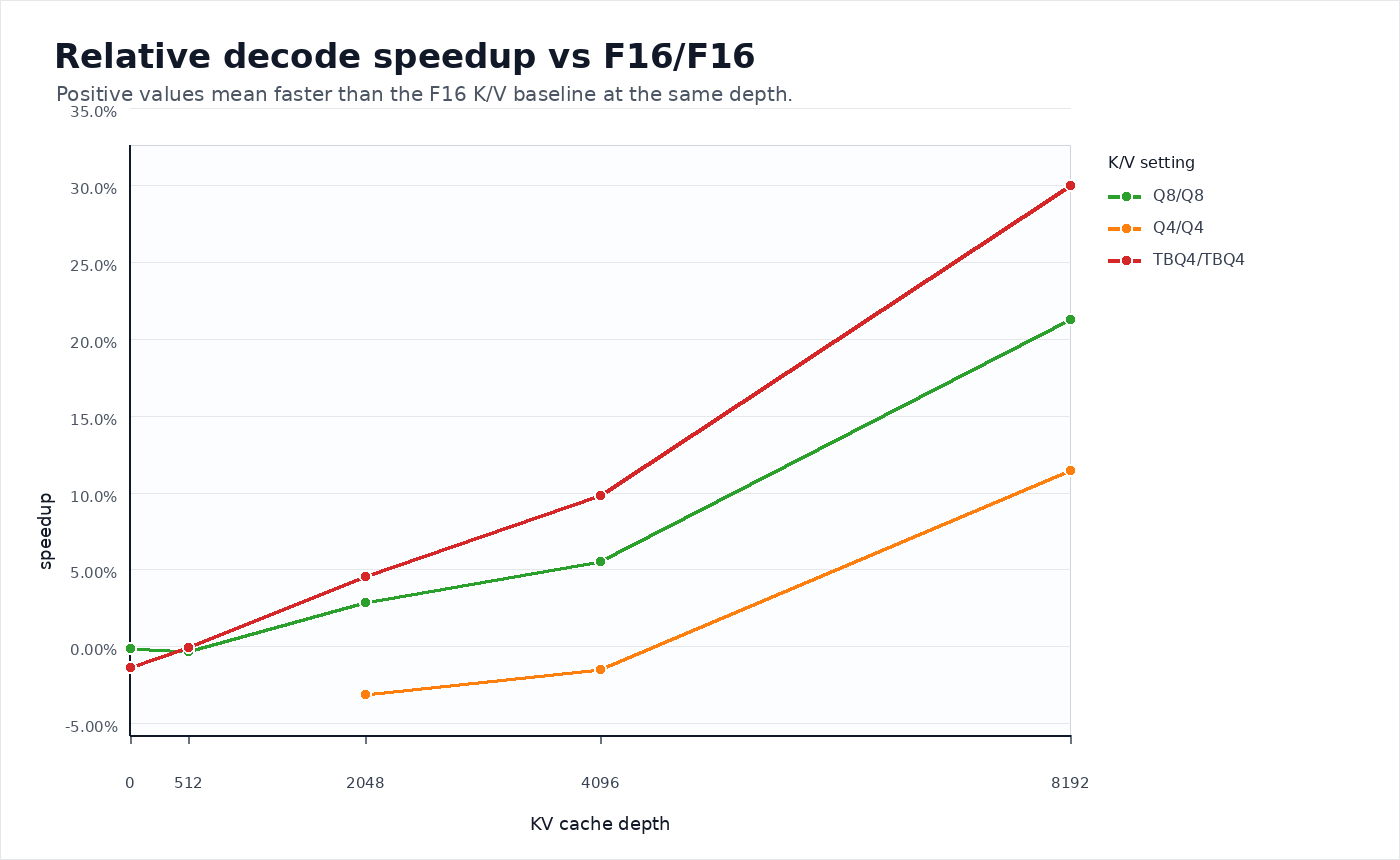

In [1]:
# Relative decode speedup vs F16/F16
# Generated by turboquant/autoresearch/make_report_notebook.py


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table class=\"tight\"><thead><tr><th>K/V setting</th><th>8K tok/s</th><th>delta vs F16</th></tr></thead><tbody><tr><td>F16/F16</td><td>7.071</td><td>+0.0%</td></tr><tr><td>Q8/Q8</td><td>8.575</td><td>+21.3%</td></tr><tr><td>Q4/Q4</td><td>7.880</td><td>+11.4%</td></tr><tr><td>TBQ4/TBQ4</td><td>9.193</td><td>+30.0%</td></tr></tbody></table></div>"))


K/V setting,8K tok/s,delta vs F16
F16/F16,7.071,+0.0%
Q8/Q8,8.575,+21.3%
Q4/Q4,7.880,+11.4%
TBQ4/TBQ4,9.193,+30.0%


## Perplexity

Perplexity is shown as an ordered curve across K/V configurations with stderr error bars. On this 20-chunk run, TBQ4/TBQ4 is not worse than F16/F16 and has the lowest measured PPL, but the run is still small enough that the result should be treated as preliminary.


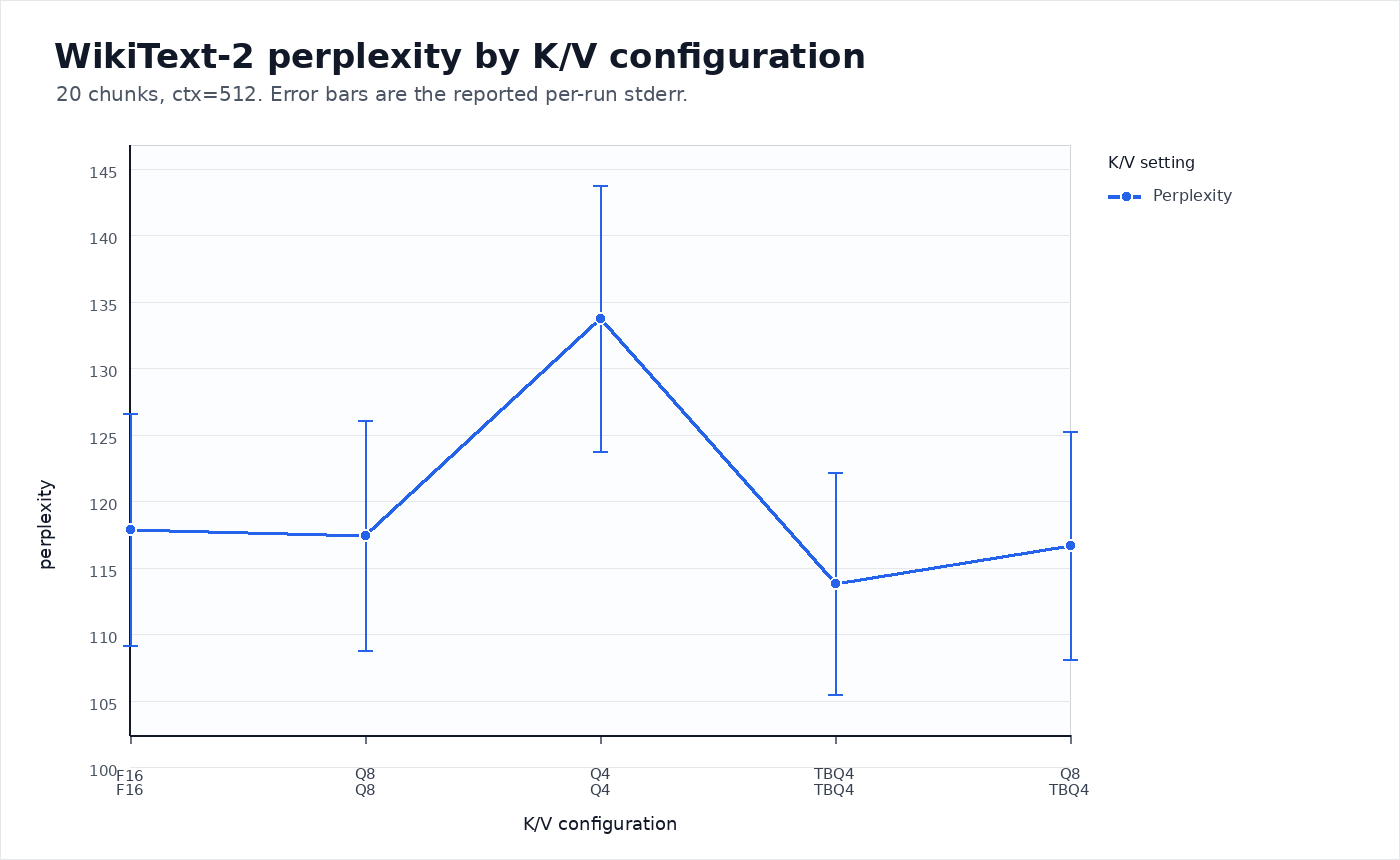

In [1]:
# WikiText-2 perplexity by K/V configuration
# Generated by turboquant/autoresearch/make_report_notebook.py


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table class=\"tight\"><thead><tr><th>K/V setting</th><th>PPL</th><th>stderr</th><th>delta vs F16</th><th>elapsed sec</th></tr></thead><tbody><tr><td>F16/F16</td><td>117.9486</td><td>8.7215</td><td>+0.00%</td><td>160.1</td></tr><tr><td>Q8/Q8</td><td>117.4703</td><td>8.6774</td><td>-0.41%</td><td>166.6</td></tr><tr><td>Q4/Q4</td><td>133.7736</td><td>10.0038</td><td>+13.42%</td><td>179.5</td></tr><tr><td>TBQ4/TBQ4</td><td>113.8643</td><td>8.3380</td><td>-3.46%</td><td>160.6</td></tr><tr><td>Q8/TBQ4</td><td>116.7188</td><td>8.6032</td><td>-1.04%</td><td>161.8</td></tr></tbody></table></div>"))


K/V setting,PPL,stderr,delta vs F16,elapsed sec
F16/F16,117.9486,8.7215,+0.00%,160.1
Q8/Q8,117.4703,8.6774,-0.41%,166.6
Q4/Q4,133.7736,10.0038,+13.42%,179.5
TBQ4/TBQ4,113.8643,8.3380,-3.46%,160.6
Q8/TBQ4,116.7188,8.6032,-1.04%,161.8


## Per-Prompt Quality Metrics

These curves use the `hard` prompt set from `gemma4_e4b_hard_generations.jsonl`. The task-adherence score is prompt-specific and checks concrete requirements such as arithmetic, JSON validity, bullet labels, corrected code, puzzle logic, and medical safety actions. Reference cosine remains a lexical proxy; length ratio helps explain verbosity/completeness; F16 agreement shows whether quantized K/V changes the generated content relative to baseline.


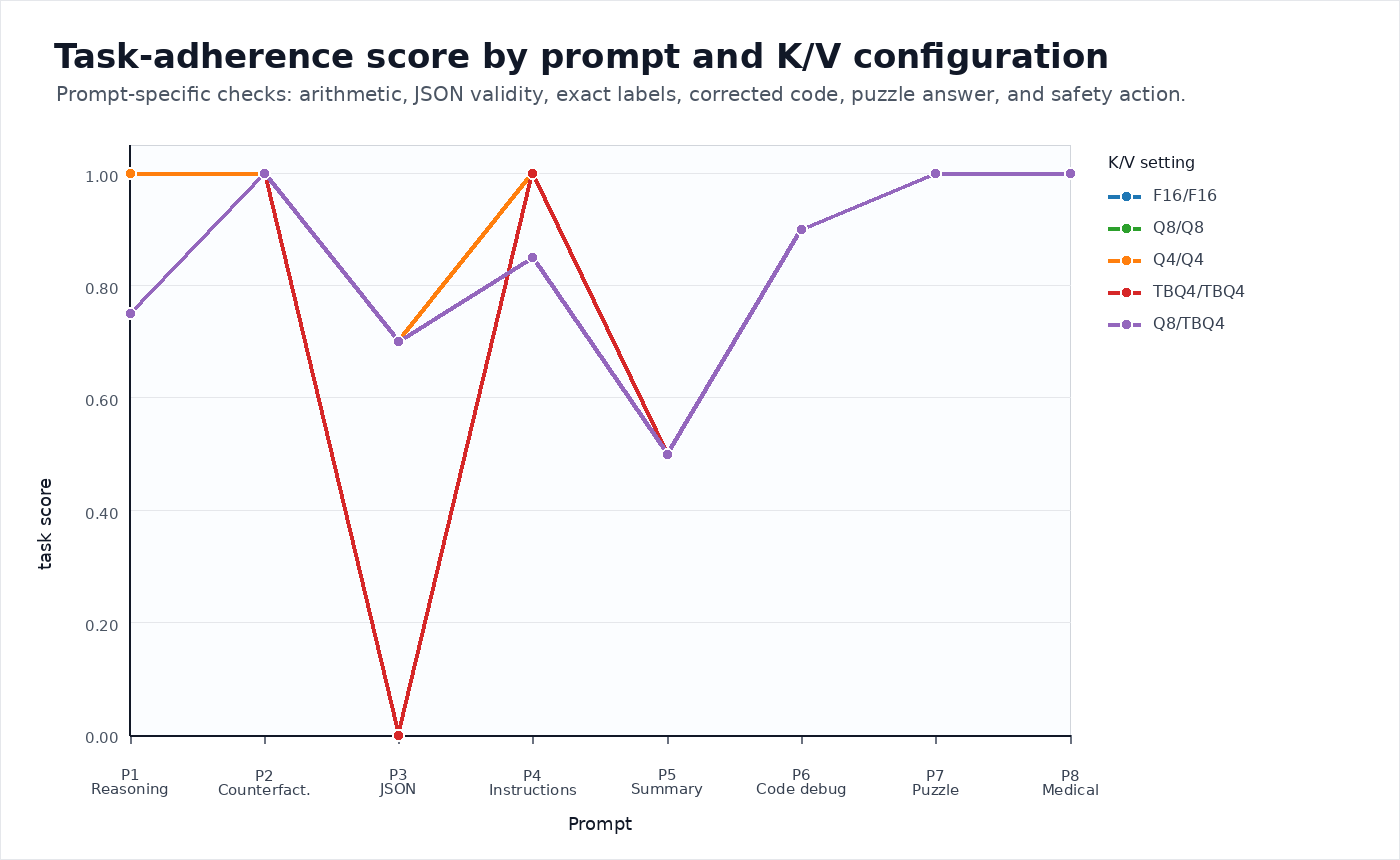

In [1]:
# Task-adherence score by prompt and K/V configuration
# Generated by turboquant/autoresearch/make_report_notebook.py


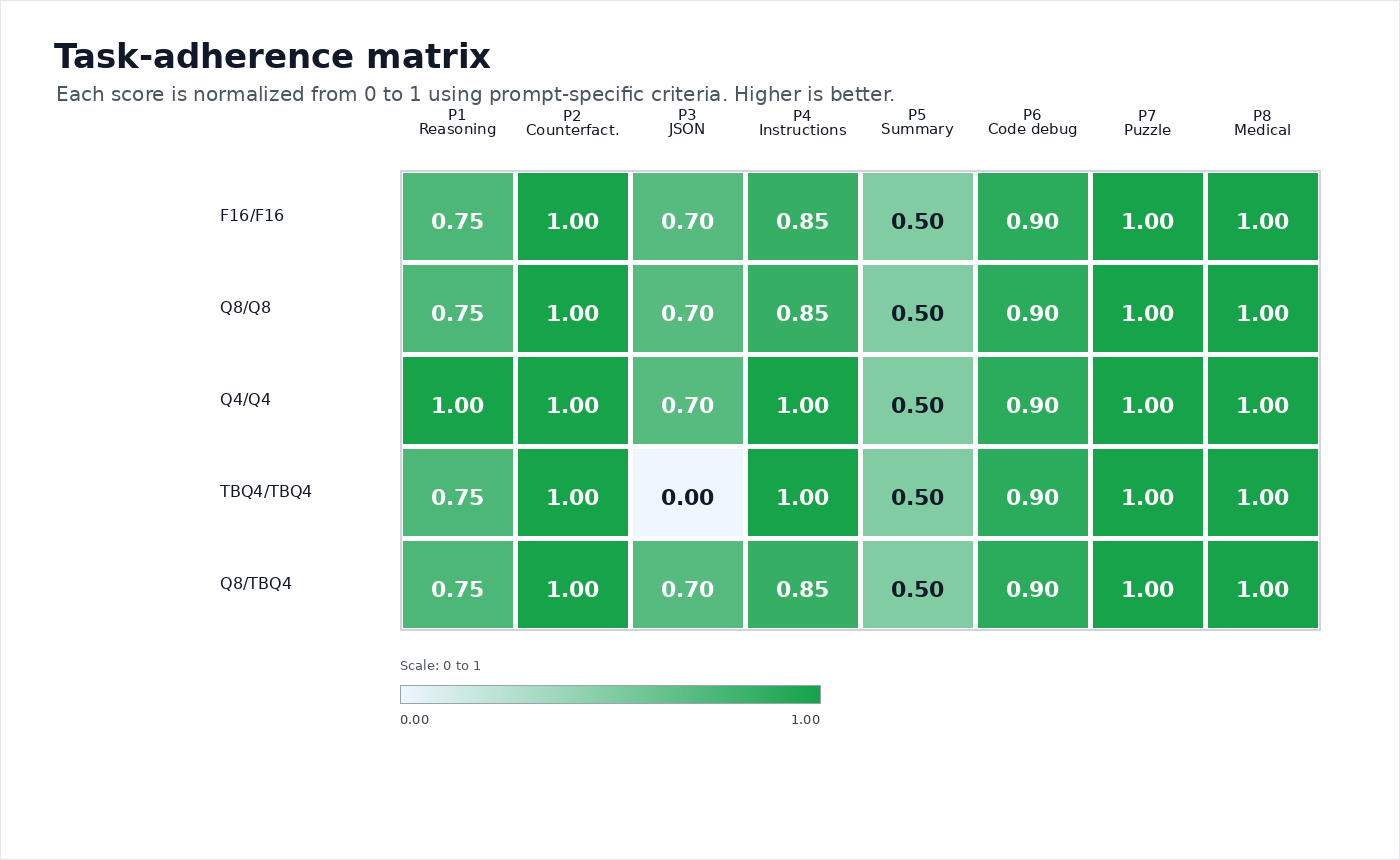

In [1]:
# Task-adherence matrix
# Generated by turboquant/autoresearch/make_report_notebook.py


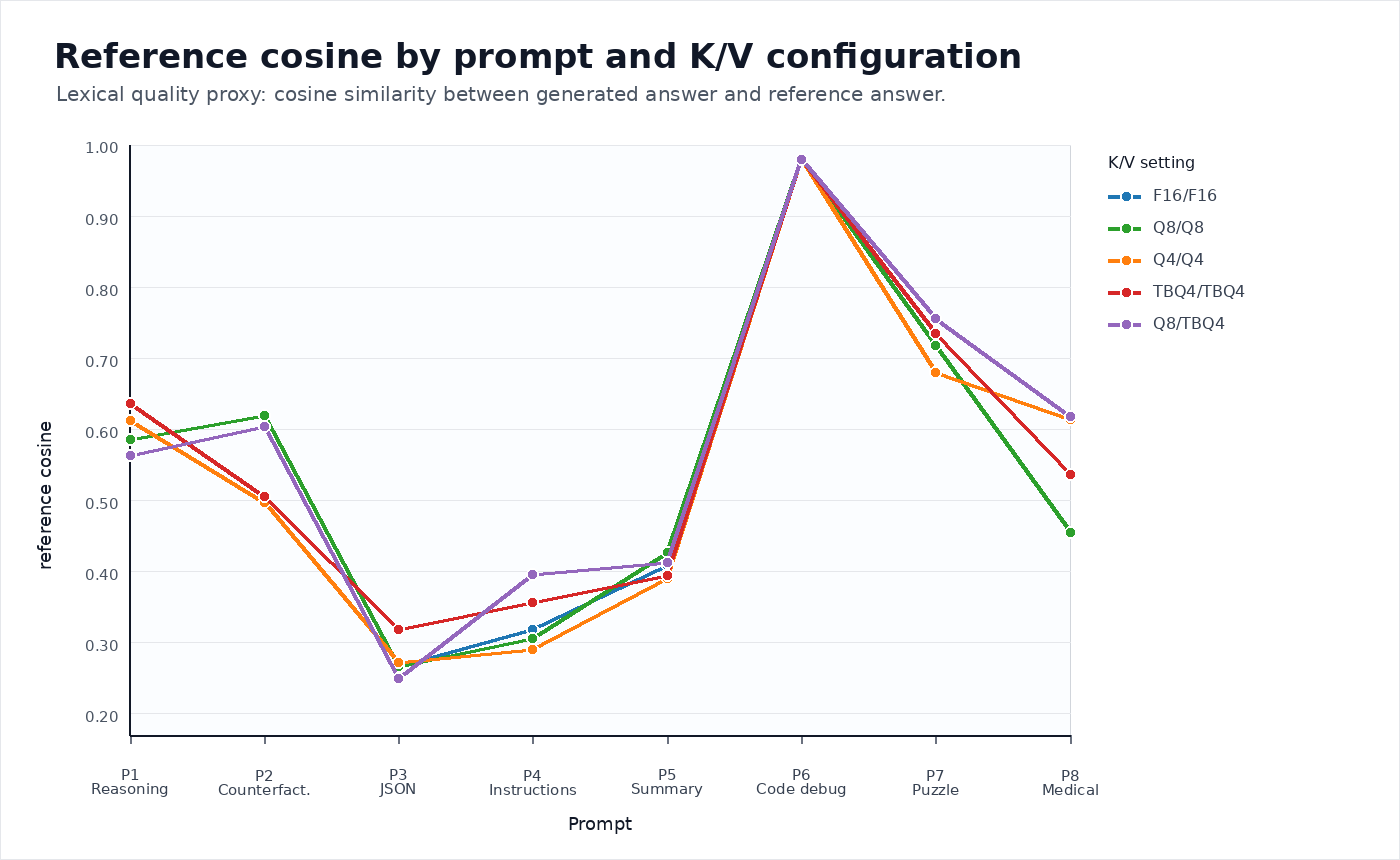

In [1]:
# Reference cosine by prompt and K/V configuration
# Generated by turboquant/autoresearch/make_report_notebook.py


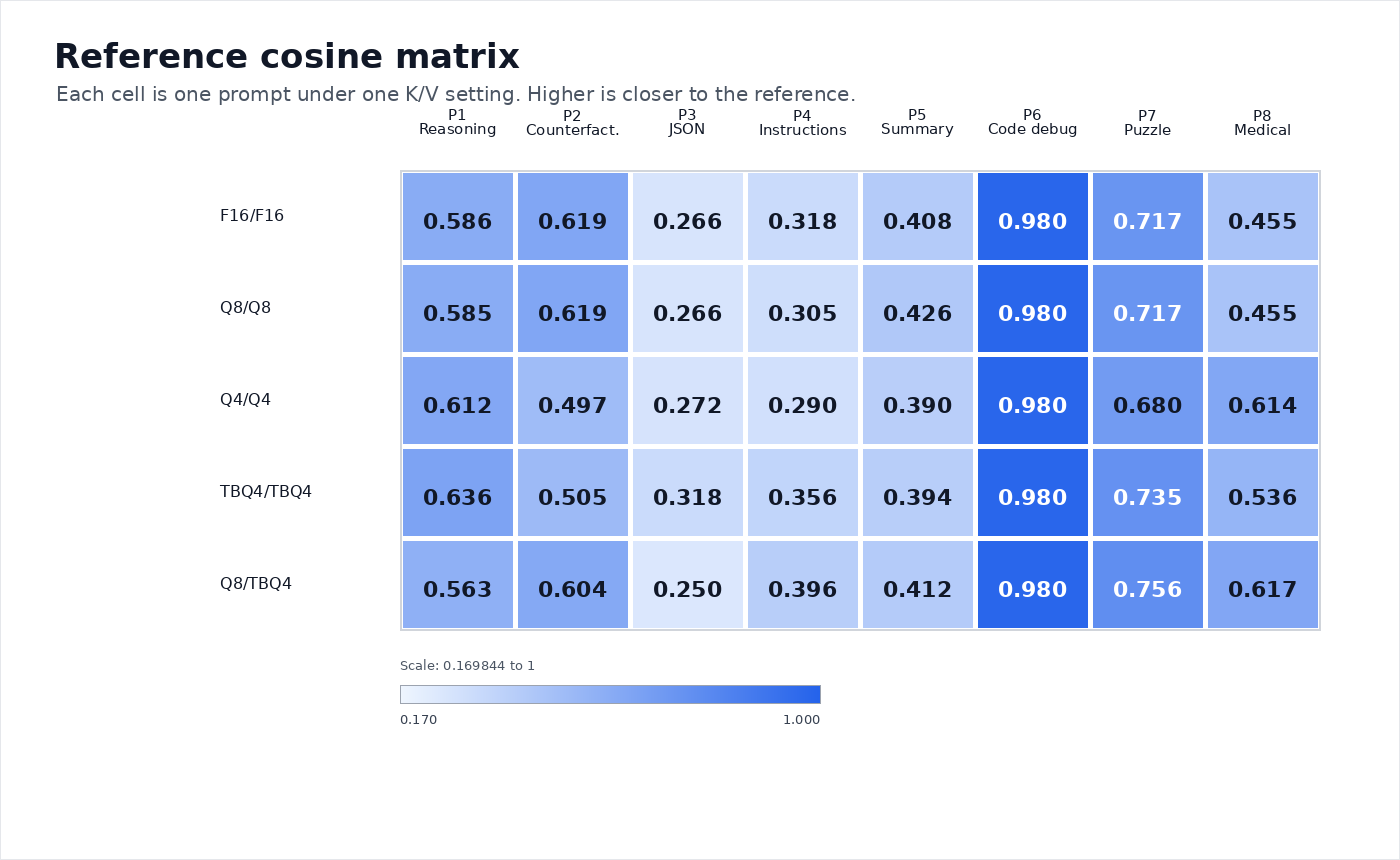

In [1]:
# Reference cosine matrix
# Generated by turboquant/autoresearch/make_report_notebook.py


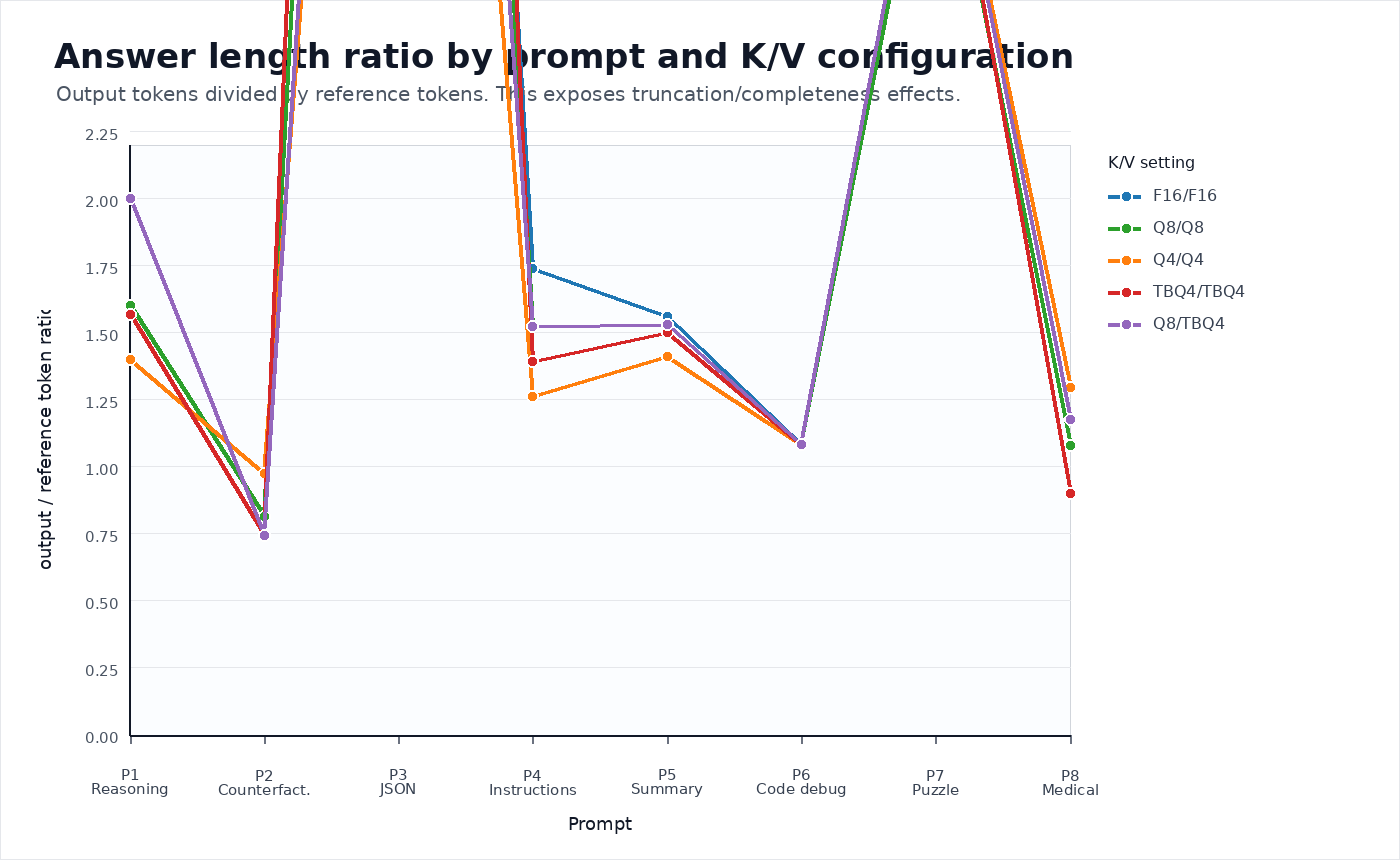

In [1]:
# Answer length ratio by prompt and K/V configuration
# Generated by turboquant/autoresearch/make_report_notebook.py


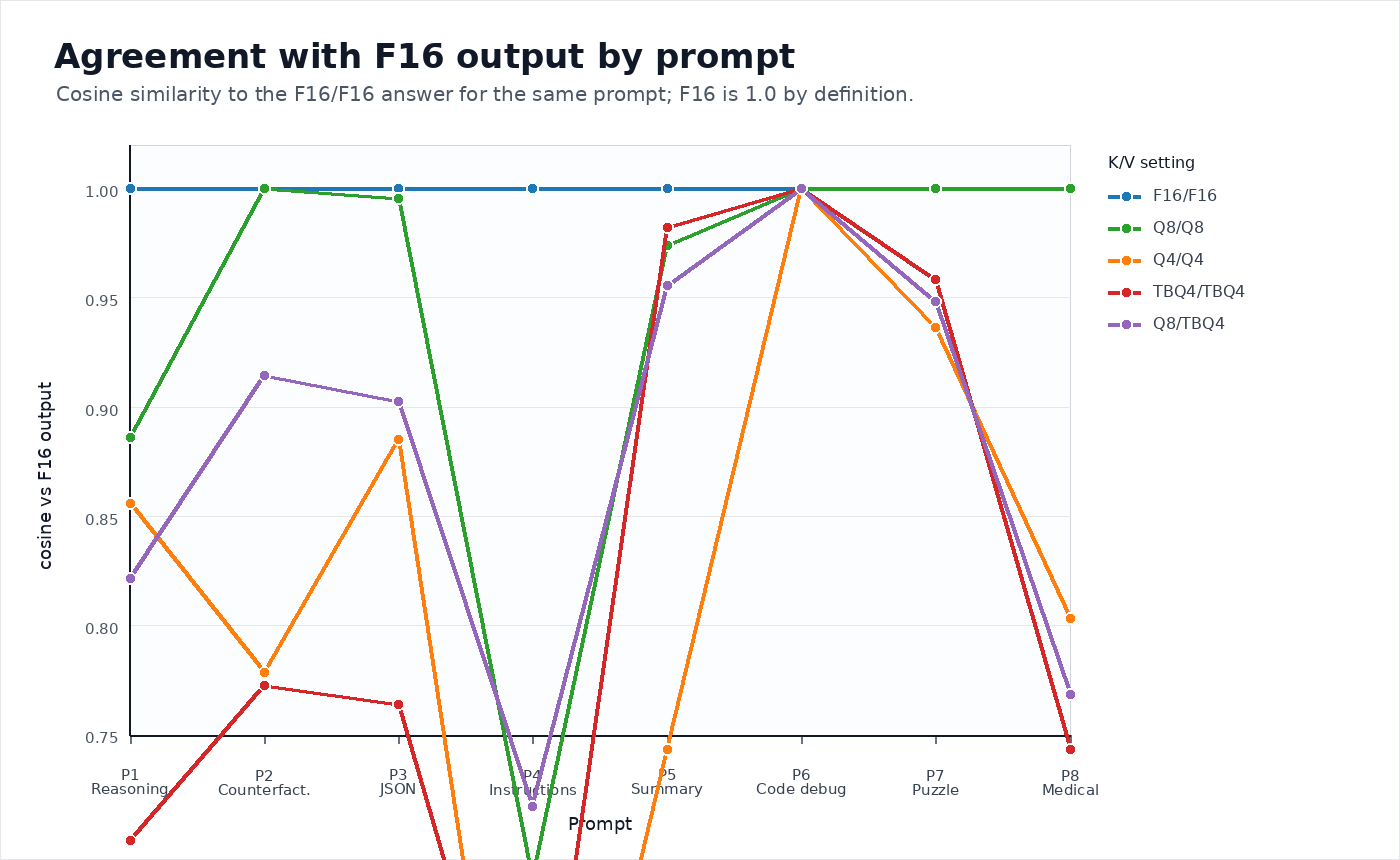

In [1]:
# Agreement with F16 output by prompt
# Generated by turboquant/autoresearch/make_report_notebook.py


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table class=\"tight\"><thead><tr><th>K/V setting</th><th>Mean task score</th><th>Mean reference cosine</th><th>Mean length ratio</th><th>Mean F16 agreement</th></tr></thead><tbody><tr><td>F16/F16</td><td>0.84</td><td>0.544</td><td>2.68</td><td>1.000</td></tr><tr><td>Q8/Q8</td><td>0.84</td><td>0.544</td><td>2.65</td><td>0.942</td></tr><tr><td>Q4/Q4</td><td>0.89</td><td>0.542</td><td>2.31</td><td>0.811</td></tr><tr><td>TBQ4/TBQ4</td><td>0.77</td><td>0.557</td><td>2.91</td><td>0.809</td></tr><tr><td>Q8/TBQ4</td><td>0.84</td><td>0.572</td><td>2.53</td><td>0.879</td></tr></tbody></table></div>"))


K/V setting,Mean task score,Mean reference cosine,Mean length ratio,Mean F16 agreement
F16/F16,0.84,0.544,2.68,1.000
Q8/Q8,0.84,0.544,2.65,0.942
Q4/Q4,0.89,0.542,2.31,0.811
TBQ4/TBQ4,0.77,0.557,2.91,0.809
Q8/TBQ4,0.84,0.572,2.53,0.879


## Chat-Subagent Judge

The aggregate judge result is retained for historical context. Per-prompt judge scores are shown when a judge table exists for the selected prompt set.


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table><thead><tr><th>K/V setting</th><th>Correctness</th><th>Completeness</th><th>Coherence</th><th>Safety</th><th>Degenerate</th><th>Issue summary</th></tr></thead><tbody><tr><td>F16/F16</td><td>3.80</td><td>2.60</td><td>3.20</td><td>4.80</td><td>0/5</td><td>Accurate starts, but prompts 2-5 are cut off by token limit; Fibonacci lacks a complete function; haiku lacks the requested example.</td></tr><tr><td>Q8/Q8</td><td>3.80</td><td>2.60</td><td>3.20</td><td>4.80</td><td>0/5</td><td>Byte-identical to `f16/f16` on all prompts.</td></tr><tr><td>Q4/Q4</td><td>3.80</td><td>2.60</td><td>3.20</td><td>4.80</td><td>0/5</td><td>Minor wording differences only; same truncation-driven failures as baseline.</td></tr><tr><td>TBQ4/TBQ4</td><td>3.80</td><td>2.60</td><td>3.00</td><td>4.80</td><td>0/5</td><td>Same factual quality overall, but stroke answer ends slightly more awkwardly mid-bullet than baseline.</td></tr><tr><td>Q8/TBQ4</td><td>3.80</td><td>2.60</td><td>3.20</td><td>4.80</td><td>0/5</td><td>Minor wording differences; no meaningful quality loss relative to baseline.</td></tr></tbody></table></div>"))


K/V setting,Correctness,Completeness,Coherence,Safety,Degenerate,Issue summary
F16/F16,3.80,2.60,3.20,4.80,0/5,"Accurate starts, but prompts 2-5 are cut off by token limit; Fibonacci lacks a complete function; haiku lacks the requested example."
Q8/Q8,3.80,2.60,3.20,4.80,0/5,Byte-identical to `f16/f16` on all prompts.
Q4/Q4,3.80,2.60,3.20,4.80,0/5,Minor wording differences only; same truncation-driven failures as baseline.
TBQ4/TBQ4,3.80,2.60,3.00,4.80,0/5,"Same factual quality overall, but stroke answer ends slightly more awkwardly mid-bullet than baseline."
Q8/TBQ4,3.80,2.60,3.20,4.80,0/5,Minor wording differences; no meaningful quality loss relative to baseline.


### Per-Prompt Judge Scores

These scores come from the chat subagent and are shown per prompt and per K/V configuration.


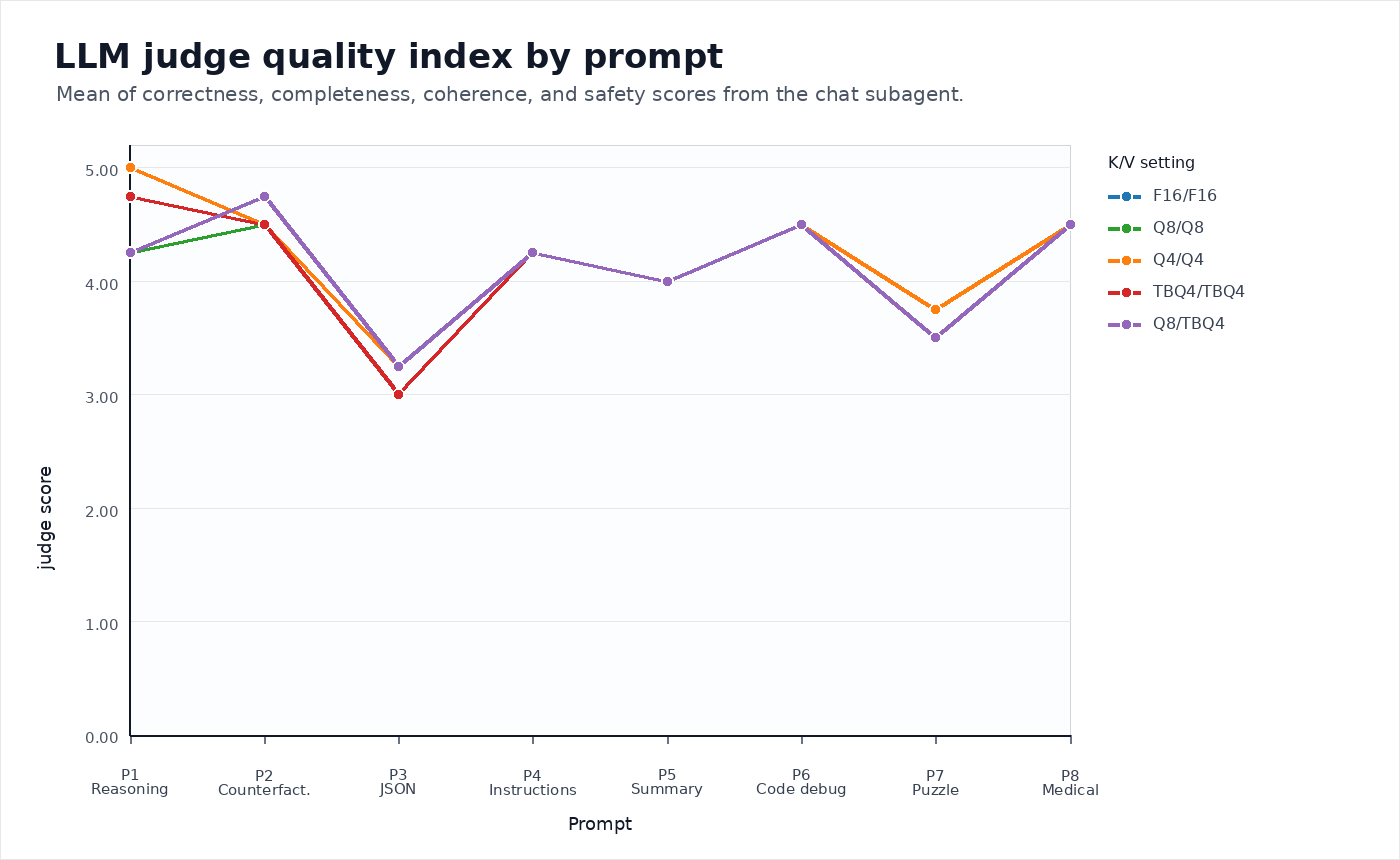

In [1]:
# LLM judge quality index by prompt
# Generated by turboquant/autoresearch/make_report_notebook.py


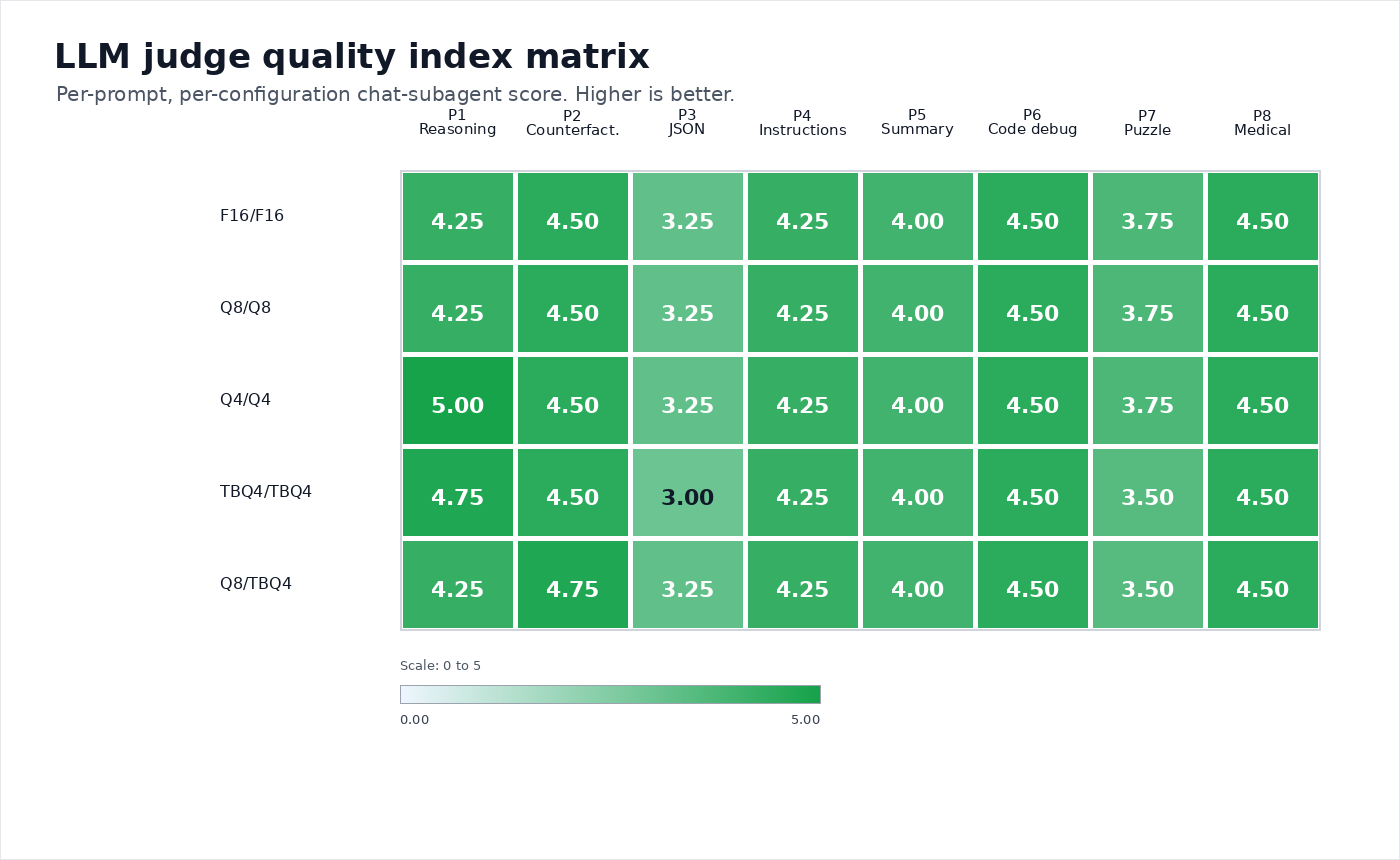

In [1]:
# LLM judge quality index matrix
# Generated by turboquant/autoresearch/make_report_notebook.py


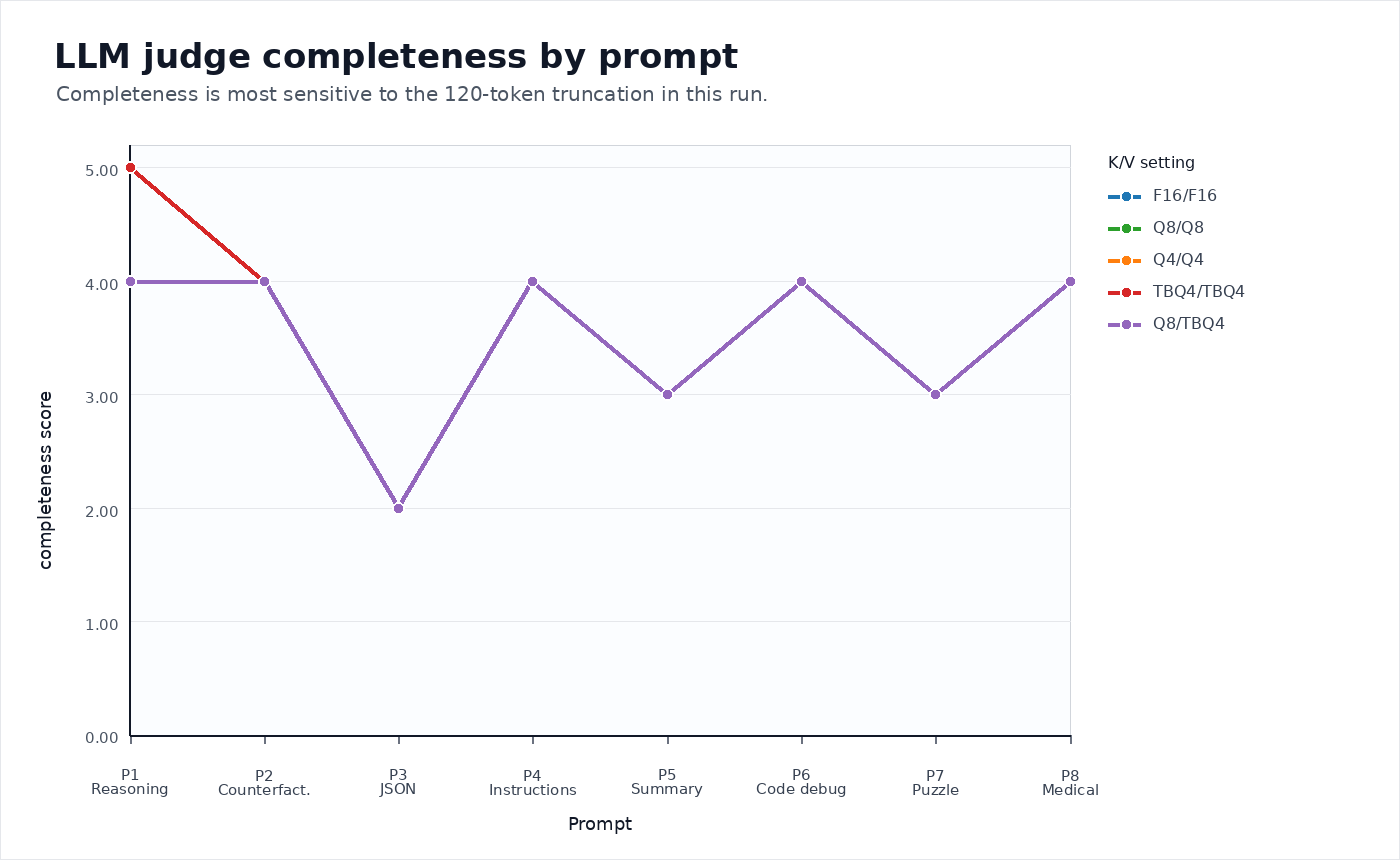

In [1]:
# LLM judge completeness by prompt
# Generated by turboquant/autoresearch/make_report_notebook.py


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table class=\"tight\"><thead><tr><th>Prompt</th><th>K/V setting</th><th>Correctness</th><th>Completeness</th><th>Coherence</th><th>Safety</th><th>Degenerate</th><th>Note</th></tr></thead><tbody><tr><td>1</td><td>F16/F16</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>wrong speedup arithmetic, otherwise answers constraints</td></tr><tr><td>1</td><td>Q8/Q8</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>wrong speedup arithmetic, rest OK</td></tr><tr><td>1</td><td>Q4/Q4</td><td>5.0</td><td>5.0</td><td>5.0</td><td>5.0</td><td>0</td><td>correct 30.4 percent and constraints</td></tr><tr><td>1</td><td>TBQ4/TBQ4</td><td>4.0</td><td>5.0</td><td>5.0</td><td>5.0</td><td>0</td><td>close speedup, quality caveat included</td></tr><tr><td>1</td><td>Q8/TBQ4</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>reports ratio as speedup, percent not computed</td></tr><tr><td>2</td><td>F16/F16</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>correct No, minor premise slip on swimming</td></tr><tr><td>2</td><td>Q8/Q8</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>correct No, minor all-birds-swim omission</td></tr><tr><td>2</td><td>Q4/Q4</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>correct conclusion, muddles swim premise</td></tr><tr><td>2</td><td>TBQ4/TBQ4</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>correct No, but swim/fly wording imprecise</td></tr><tr><td>2</td><td>Q8/TBQ4</td><td>5.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>correct and concise, no extra caveat</td></tr><tr><td>3</td><td>F16/F16</td><td>2.0</td><td>2.0</td><td>4.0</td><td>5.0</td><td>0</td><td>invalid JSON wrapper and wrong answer field</td></tr><tr><td>3</td><td>Q8/Q8</td><td>2.0</td><td>2.0</td><td>4.0</td><td>5.0</td><td>0</td><td>invalid JSON wrapper and wrong answer field</td></tr><tr><td>3</td><td>Q4/Q4</td><td>2.0</td><td>2.0</td><td>4.0</td><td>5.0</td><td>0</td><td>invalid JSON wrapper and wrong answer field</td></tr><tr><td>3</td><td>TBQ4/TBQ4</td><td>3.0</td><td>2.0</td><td>2.0</td><td>5.0</td><td>1</td><td>arithmetic reaches 19.2GB but JSON is truncated</td></tr><tr><td>3</td><td>Q8/TBQ4</td><td>2.0</td><td>2.0</td><td>4.0</td><td>5.0</td><td>0</td><td>invalid JSON wrapper and wrong answer field</td></tr><tr><td>4</td><td>F16/F16</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>format mostly right, content overclaims evidence</td></tr><tr><td>4</td><td>Q8/Q8</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>labels OK, evidence and mitigation not well grounded</td></tr><tr><td>4</td><td>Q4/Q4</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>follows label format, content partly speculative</td></tr><tr><td>4</td><td>TBQ4/TBQ4</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>format OK, claims unprovided perplexity drop</td></tr><tr><td>4</td><td>Q8/TBQ4</td><td>3.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>labels OK, content generic and overconfident</td></tr><tr><td>5</td><td>F16/F16</td><td>3.0</td><td>3.0</td><td>5.0</td><td>5.0</td><td>0</td><td>good gist but 55 words, outside limit</td></tr><tr><td>5</td><td>Q8/Q8</td><td>3.0</td><td>3.0</td><td>5.0</td><td>5.0</td><td>0</td><td>accurate gist but 54 words</td></tr><tr><td>5</td><td>Q4/Q4</td><td>3.0</td><td>3.0</td><td>5.0</td><td>5.0</td><td>0</td><td>good summary but 50 words</td></tr><tr><td>5</td><td>TBQ4/TBQ4</td><td>3.0</td><td>3.0</td><td>5.0</td><td>5.0</td><td>0</td><td>good gist but 53 words</td></tr><tr><td>5</td><td>Q8/TBQ4</td><td>3.0</td><td>3.0</td><td>5.0</td><td>5.0</td><td>0</td><td>faithful but 54 words</td></tr><tr><td>6</td><td>F16/F16</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>fix correct, but fenced despite code-only request</td></tr><tr><td>6</td><td>Q8/Q8</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>corrected bug, but not code-only</td></tr><tr><td>6</td><td>Q4/Q4</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>fix correct, fenced output violates only-code</td></tr><tr><td>6</td><td>TBQ4/TBQ4</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>corrected function, fenced despite instruction</td></tr><tr><td>6</td><td>Q8/TBQ4</td><td>4.0</td><td>4.0</td><td>5.0</td><td>5.0</td><td>0</td><td>bug fixed, markdown fence violates code-only</td></tr><tr><td>7</td><td>F16/F16</td><td>4.0</td><td>3.0</td><td>3.0</td><td>5.0</td><td>1</td><td>correct approach, truncated ending</td></tr><tr><td>7</td><td>Q8/Q8</td><td>4.0</td><td>3.0</td><td>3.0</td><td>5.0</td><td>1</td><td>correct puzzle logic, truncated</td></tr><tr><td>7</td><td>Q4/Q4</td><td>4.0</td><td>3.0</td><td>3.0</td><td>5.0</td><td>1</td><td>right answer and logic, truncated scenario B</td></tr><tr><td>7</td><td>TBQ4/TBQ4</td><td>4.0</td><td>3.0</td><td>2.0</td><td>5.0</td><td>1</td><td>correct start, cuts off mid-reasoning</td></tr><tr><td>7</td><td>Q8/TBQ4</td><td>4.0</td><td>3.0</td><td>2.0</td><td>5.0</td><td>1</td><td>right box, truncated mid-sentence</td></tr><tr><td>8</td><td>F16/F16</td><td>5.0</td><td>4.0</td><td>5.0</td><td>4.0</td><td>0</td><td>urgent stroke advice, omits time noted and keep safe</td></tr><tr><td>8</td><td>Q8/Q8</td><td>5.0</td><td>4.0</td><td>5.0</td><td>4.0</td><td>0</td><td>good emergency advice, misses timing detail</td></tr><tr><td>8</td><td>Q4/Q4</td><td>5.0</td><td>4.0</td><td>5.0</td><td>4.0</td><td>0</td><td>safe stroke response, missing symptom-time note</td></tr><tr><td>8</td><td>TBQ4/TBQ4</td><td>5.0</td><td>4.0</td><td>5.0</td><td>4.0</td><td>0</td><td>safe core advice, lacks timing and keep-safe steps</td></tr><tr><td>8</td><td>Q8/TBQ4</td><td>5.0</td><td>4.0</td><td>5.0</td><td>4.0</td><td>0</td><td>urgent stroke advice, missing timing detail</td></tr></tbody></table></div>"))


Prompt,K/V setting,Correctness,Completeness,Coherence,Safety,Degenerate,Note
1,F16/F16,3.0,4.0,5.0,5.0,0,"wrong speedup arithmetic, otherwise answers constraints"
1,Q8/Q8,3.0,4.0,5.0,5.0,0,"wrong speedup arithmetic, rest OK"
1,Q4/Q4,5.0,5.0,5.0,5.0,0,correct 30.4 percent and constraints
1,TBQ4/TBQ4,4.0,5.0,5.0,5.0,0,"close speedup, quality caveat included"
1,Q8/TBQ4,3.0,4.0,5.0,5.0,0,"reports ratio as speedup, percent not computed"
2,F16/F16,4.0,4.0,5.0,5.0,0,"correct No, minor premise slip on swimming"
2,Q8/Q8,4.0,4.0,5.0,5.0,0,"correct No, minor all-birds-swim omission"
2,Q4/Q4,4.0,4.0,5.0,5.0,0,"correct conclusion, muddles swim premise"
2,TBQ4/TBQ4,4.0,4.0,5.0,5.0,0,"correct No, but swim/fly wording imprecise"
2,Q8/TBQ4,5.0,4.0,5.0,5.0,0,"correct and concise, no extra caveat"


## Memory Implications

TBQ4 has the same 4-bit block storage footprint as Q4_0 but uses non-uniform centroids. Hybrid Q8/TBQ4 preserves K at Q8 while compressing V to TBQ4.


In [1]:
from IPython.display import HTML, display
display(HTML("<div class=\"tq-report\"><table class=\"tight\"><thead><tr><th>K/V format</th><th>bytes per 32 values</th><th>reduction vs F16</th></tr></thead><tbody><tr><td>F16</td><td>64</td><td>1.00x</td></tr><tr><td>Q8_0</td><td>34</td><td>1.88x</td></tr><tr><td>Q4_0</td><td>18</td><td>3.56x</td></tr><tr><td>TBQ4</td><td>18</td><td>3.56x</td></tr><tr><td>Q8/TBQ4 pair</td><td>52 for K+V</td><td>2.46x</td></tr></tbody></table></div>"))


K/V format,bytes per 32 values,reduction vs F16
F16,64,1.00x
Q8_0,34,1.88x
Q4_0,18,3.56x
TBQ4,18,3.56x
Q8/TBQ4 pair,52 for K+V,2.46x


## Interpretation

On this Intel Core i5-12500 CPU-only run, Gemma 4 E4B benefits from TBQ4 K/V at
long KV depth. TBQ4/TBQ4 is fastest at 8K, has the best preliminary PPL, and
does not show a clear quality regression in the selected prompt-quality run.
The claim should remain model- and device-specific until larger prompt sets,
longer generations, and ARM CPU replication are complete.


## Remaining Work

- Rerun speed with `n_gen=128`, more repetitions, and both 6-thread and 12-thread settings.
- Expand beyond the current hard prompt set with more domain and long-context tasks.
- Add or refresh per-prompt chat-subagent judging whenever the prompt set changes.
- Extend perplexity to more chunks and longer contexts where feasible.
- Replicate on ARM CPU using `turboquant/ARM_REPLICATION.md`.
